# Tıbbi Görüntü Ön İşleme (Data Preprocessing Pipeline)
Bu notebook, cilt ve göz hastalıkları teşhis modelinde kullanılacak görüntülerin eğitim öncesi temizlenmesi, standardize edilmesi ve modele uygun hale getirilmesi için gereken fonksiyonları içerir.

In [16]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# TensorFlow versiyon kontrolü
print(f"TensorFlow Versiyonu: {tf.__version__}")
print(f"OpenCV Versiyonu: {cv2.__version__}")

TensorFlow Versiyonu: 2.21.0
OpenCV Versiyonu: 4.10.0


## Ön İşleme Fonksiyonu: `preprocess_medical_image`
Bu fonksiyon sırasıyla şu işlemleri uygular:
1. **Yeniden Boyutlandırma (Resizing):** Modellerin (örn. ResNet, MobileNet) beklediği standart boyuta (varsayılan 224x224) getirir.
2. **Gürültü Temizleme (Noise Reduction):** Gaussian Blur kullanarak görüntüdeki istenmeyen küçük piksel bozulmalarını yumuşatır.
3. **Kontrast Ayarı (CLAHE):** Tıbbi görüntülerdeki kılcal damar veya lezyon sınırlarını belirginleştirmek için Adaptif Histogram Eşitleme (CLAHE) kullanır.
4. **Normalizasyon:** Piksel değerlerini [0, 255] aralığından [0, 1] aralığına çeker ve TensorFlow Tensor formatına dönüştürür.

In [ ]:
def preprocess_medical_image(image_path, target_size=(224, 224)):
    """
    Tıbbi görüntüleri en-boy oranını koruyarak, netleştirip kontrastını artırarak hazırlar.
    """
    # 1. Görüntüyü Oku ve RGB'ye Çevir
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Görüntü okunamadı. Dosya yolunu kontrol edin: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. EN-BOY ORANINI KORUYARAK Yeniden Boyutlandırma (Padding)
    h, w = img_rgb.shape[:2]
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    img_scaled = cv2.resize(img_rgb, (new_w, new_h))
    
    delta_w = target_w - new_w
    delta_h = target_h - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    img_padded = cv2.copyMakeBorder(img_scaled, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    # 3. Gürültü Temizleme (Daha hafif bir bulanıklık veriyoruz: 3x3 kernel)
    img_denoised = cv2.GaussianBlur(img_padded, (3, 3), 0)

    # ---> YENİ: 3.5 NETLİK (Sharpening - Unsharp Mask) İşlemi <---
    # Orijinal resimden biraz daha bulanık bir kopya çıkarıp farkını alarak kenarları keskinleştiriyoruz
    gaussian_blur_for_sharpness = cv2.GaussianBlur(img_denoised, (0, 0), 2.0)
    img_sharpened = cv2.addWeighted(img_denoised, 1.5, gaussian_blur_for_sharpness, -0.5, 0)

    # 4. KONTRAST Ayarı (CLAHE)
    lab = cv2.cvtColor(img_sharpened, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    
    # ---> YENİ: clipLimit=3.0 yaparak kontrastı daha da güçlendirdik <---
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    
    limg = cv2.merge((cl, a, b))
    img_contrast = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # 5. Normalizasyon ve TensorFlow Dönüşümü
    img_normalized = img_contrast / 255.0
    img_tensor = tf.convert_to_tensor(img_normalized, dtype=tf.float32)

    return img_rgb, img_tensor, img_contrast

## Fonksiyon Testi ve Karşılaştırma
Geliştirilen fonksiyon örnek bir cilt (melanom) veya göz (fundus) fotoğrafı üzerinde test edilir. Orijinal görüntü ile ön işleme adımlarından geçmiş görüntü yan yana karşılaştırılır.

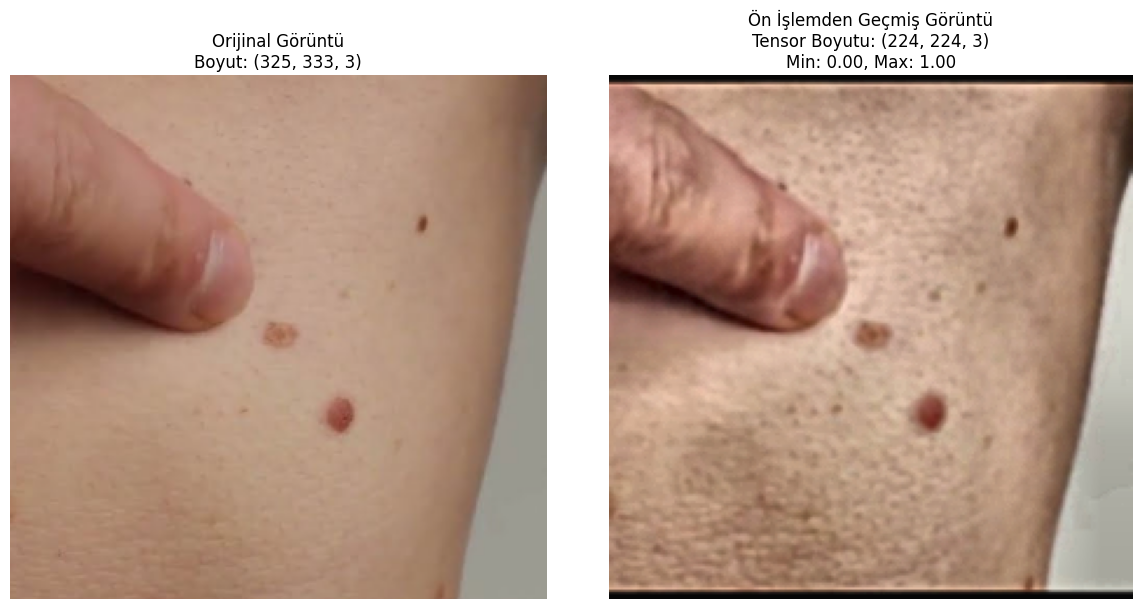

In [18]:
def visualize_preprocessing(image_path):
    try:
        # Fonksiyonu çağır
        original_img, tensor_img, processed_img = preprocess_medical_image(image_path)
        
        # Görselleştirme
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # Orijinal Görüntü
        axes[0].imshow(original_img)
        axes[0].set_title(f"Orijinal Görüntü\nBoyut: {original_img.shape}")
        axes[0].axis('off')
        
        # İşlenmiş Görüntü
        axes[1].imshow(processed_img)
        axes[1].set_title(f"Ön İşlemden Geçmiş Görüntü\nTensor Boyutu: {tensor_img.shape}\nMin: {tf.reduce_min(tensor_img):.2f}, Max: {tf.reduce_max(tensor_img):.2f}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.savefig("on_isleme_sonucu.png")
        plt.show()
        
    except Exception as e:
        print(f"Hata: {e}")

# --- TEST ADIMI ---
# Buraya bilgisayarınızdaki veya projenizdeki bir örnek resmin yolunu yazın.
# Örnek: 'veri_seti/sample_melanoma.jpg'
ornek_resim_yolu = "test_resmi.jpg" 

# Test fonksiyonunu çalıştır
# Eğer elinizde resim yoksa önce bir tane indirip aynı dizine koyun.
# visualize_preprocessing(ornek_resim_yolu)
visualize_preprocessing("test_resmi.jpg")